In [1]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic (GPU/CPU) --
def get_system_info():
    if torch.cuda.is_available():
        return f"GPU: {torch.cuda.get_device_name(0)}"
    else:
        return f"CPU: {os.cpu_count()}"

get_system_info()

'GPU: Tesla T4'

In [2]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_token = user_secrets.get_secret("pfn_key")

USE_PFN_TOKEN = True
RUN_LOCAL     = True

if RUN_LOCAL:
    print("Loading tabpfn_local... ")
    os.environ["TABPFN_MODEL_CACHE_DIR"] = "/kaggle/input/models/prior-labsai/tabpfn-3-5/pytorch/default/1"
    try:
        from tabpfn import TabPFNClassifier
    except:
        !uv pip install tabpfn
        from tabpfn import TabPFNClassifier
    ## -----------------------------------------------------
    # if USE_PFN_TOKEN: # Option 1: Use secret token key
    #     os.environ["TABPFN_TOKEN"] = secret_token
    # else: # Option 2: Access to direct model
    #     os.environ["TABPFN_MODEL_CACHE_DIR"] = "/kaggle/input/models/prior-labsai/tabpfn-3-5/pytorch/default/1"
    print("Complete!")
else:
    print("Connecting tabpfn_client... ", end='')
    try:
        import tabpfn_client
        from tabpfn_client import TabPFNClassifier, set_access_token, get_api_usage
    except:
        !uv pip install tabpfn-client
        import tabpfn_client
        from tabpfn_client import TabPFNClassifier, set_access_token, get_api_usage
    tabpfn_client.set_access_token(secret_token)

    print("Complete!")
    print(get_api_usage())

Loading tabpfn_local... 
Using Python 3.13.15 environment at: /usr
Resolved 74 packages in 636ms                                        
Prepared 3 packages in 40ms                                              
Installed 3 packages in 6ms                                 
 + pydantic-settings==2.15.0
 + skrub==0.10.1
 + tabpfn==9.1.0
Complete!


In [3]:
## -- Data Manipulation -- 
import numpy as np, pandas as pd, random
from scipy.optimize import minimize

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
import itertools
from tqdm.notebook import tqdm
from time import time, sleep

## -- Machine Learning --
# if torch.cuda.is_available():
#     import cudf
#     from cuml.preprocessing import TargetEncoder as cumlTE
#     from cuml.model_selection import KFold, train_test_split
#     from cuml.metrics import roc_auc_score
# else:
from sklearn.preprocessing import TargetEncoder as skTE
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import roc_auc_score

from sklearn.calibration import CalibrationDisplay
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

from sklearn.utils.class_weight import compute_class_weight

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

## -- Global Settings --
# sklearn.set_config(transform_output='pandas')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
# sns.set_style("whitegrid")
# plt.style.use('ggplot')

warnings

<module 'warnings' from '/usr/lib/python3.13/warnings.py'>

In [4]:
TEAL, GOLD, CORAL, BLUE, DARK, CRIM, MUTED, INK, PAPER = '#168c91','#e8b44f','#dc705a',\
                                                         'dodgerblue','#0B4F7A','crimson',\
                                                         '#627D98','#102A43','#faf9f5'
plt.rcParams.update({
    'figure.facecolor': PAPER,
    'axes.facecolor': PAPER,
    'savefig.facecolor': PAPER,
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.titlesize': 13,
    'axes.titleweight': 'semibold',
    'axes.labelcolor': INK,
    'text.color': INK,
    'xtick.color': DARK,
    'ytick.color': DARK,
    'axes.edgecolor': MUTED,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.color': MUTED,
    'patch.edgecolor': DARK,
    # 'patch.force_edgecolor': True,
    # 'patch.linewidth': 1.5,
    # 'figure.dpi':110,
    # 'savefig.dpi':160,
})
# CMAP = LinearSegmentedColormap.from_list('atlas', ['#f0f5ef','#a9d6ca',TEAL,INK])
sns.set_palette([TEAL, GOLD, CORAL, BLUE, MUTED, CRIM, DARK, INK, PAPER])

## -- Set Global Seed --
CFG = {
    'FOLDS':  5,
    'SEED':   42,
    'GREEN':  '\033[32m',
    'YELLOW': '\033[33m',
    'RESET':  '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [5]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = "kaggle" # -> 'colab' 'kaggle'

if PLATFORM == "kaggle":
    PATH = "/kaggle/input/competitions/playground-series-s6e10/"
    submit = pd.read_csv(PATH+"sample_submission.csv")
    train = pd.read_csv(PATH+"train.csv")
    test = pd.read_csv(PATH+"test.csv")

    ORIG_PATH = "/kaggle/input/datasets/arseniyshutko/binary-aviation-satisfaction-129k/"
    orig = pd.read_csv(ORIG_PATH+"data.csv")
elif PLATFORM == "colab":
    from google.colab import drive
    drive.mount("/content/drive")

    PATH   = "/content/drive/MyDrive/-- shared_notebooks --/Ps6e10 | Airline Satisfaction/_airline_data/"
    submit = pd.read_csv(PATH+"sample_submission.csv")
    train  = pd.read_csv(PATH+"train.csv")
    test   = pd.read_csv(PATH+"test.csv")
    orig = pd.read_csv(PATH+"data.csv")

# if torch.cuda.is_available():
#     submit = cudf.DataFrame(submit)
#     train = cudf.DataFrame(train)
#     test = cudf.DataFrame(test)
#     orig = cudf.DataFrame(orig)

## =================================================================================

TARGET, ID = 'satisfaction', 'id'

train[TARGET] = train[TARGET].map({True: 1, False: 0})
orig[TARGET] = orig[TARGET].map({True: 1, False: 0})

obj = train.select_dtypes(include=["object", "category"]).columns.tolist()

cat_cols  = [c for c in obj if c not in [TARGET, ID]]
num_cols  = [c for c in train.columns if c not in cat_cols+[TARGET, ID]]
base_cols = [c for c in train.columns if c not in [TARGET, ID]]

train = train[base_cols+[TARGET]]
orig  = orig[base_cols+[TARGET]]
test  = test[base_cols]

for (name, df) in {"Train": train, "Test": test, 'Orig': orig}.items(): #
    print(f"{name} shape: {df.shape}")

print(f"\nFrame type: {type(train)}")
print(f"Total Numerical: {len(num_cols)}")
print(f"Total Categorical: {len(cat_cols)}")
print(f"Total base features: {len(base_cols)}")

Train shape: (699635, 22)
Test shape: (299844, 21)
Orig shape: (129880, 22)

Frame type: <class 'pandas.core.frame.DataFrame'>
Total Numerical: 17
Total Categorical: 4
Total base features: 21


In [6]:
train.head()

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender,Customer Type,Type of Travel,Class,satisfaction
0,36,694,4,4,4,3,1,4,1,1,3,4,4,3,1,0,0.0,Female,Loyal Customer,Personal Travel,Eco,0
1,56,651,5,5,5,5,5,4,4,5,5,5,5,4,3,0,0.0,Male,Loyal Customer,Business travel,Business,1
2,31,1371,3,4,2,5,3,3,3,3,4,3,4,5,3,0,0.0,Female,Loyal Customer,Personal Travel,Eco,0
3,10,1616,3,5,3,3,3,3,3,3,4,5,3,4,3,0,0.0,Male,Loyal Customer,Personal Travel,Eco,0
4,23,481,3,4,3,4,5,3,5,5,5,4,5,3,5,5,0.0,Female,disloyal Customer,Business travel,Eco,0


In [7]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,699635.0,39.001928,13.800943,7.0,27.0,40.0,50.0,85.0
Flight Distance,699635.0,1353.778702,954.422566,67.0,631.0,954.0,1814.0,4983.0
Inflight wifi service,699635.0,2.778722,1.280419,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,699635.0,3.156210,1.475390,0.0,2.0,3.0,4.0,5.0
Ease of Online booking,699635.0,2.813240,1.329550,0.0,2.0,3.0,4.0,5.0
Gate location,699635.0,3.013734,1.254014,0.0,2.0,3.0,4.0,5.0
Food and drink,699635.0,3.265644,1.300202,0.0,2.0,3.0,4.0,5.0
Online boarding,699635.0,3.364156,1.288538,0.0,2.0,4.0,4.0,5.0
Seat comfort,699635.0,3.568950,1.275333,0.0,3.0,4.0,5.0,5.0
Inflight entertainment,699635.0,3.453910,1.308157,0.0,2.0,4.0,5.0,5.0


In [8]:
n_unique = train[base_cols].nunique().sort_values()
n_unique

Customer Type                           2
Type of Travel                          2
Gender                                  2
Class                                   3
Baggage handling                        5
Departure/Arrival time convenient       6
Gate location                           6
Inflight wifi service                   6
Leg room service                        6
Checkin service                         6
On-board service                        6
Inflight entertainment                  6
Food and drink                          6
Online boarding                         6
Seat comfort                            6
Ease of Online booking                  6
Cleanliness                             6
Age                                    75
Departure Delay in Minutes            167
Arrival Delay in Minutes              168
Flight Distance                      3474
dtype: int64

In [9]:
def get_class_weights(y):
    """
    y: Current y_labels -> array_like or series
    """
    wts = compute_class_weight('balanced', classes=np.unique(y), y=y)
    return wts

def get_sample_weights(y, y_true):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    """
    cls = np.unique(y_true)
    wts = compute_class_weight('balanced', classes=cls, y=y_true)
    class_weights = dict(zip(cls, wts))
    return np.array([class_weights[label] for label in y])

print('- Helper Functions Ready -')

- Helper Functions Ready -


In [10]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the
        global mean. If 'auto', an empirical Bayes estimate is used.

    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'

                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)

                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups

                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)

                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}

        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)

        return X

In [11]:
def original_TE(
    orig: pd.DataFrame,
    df: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return df.copy()

    if aggs is None or len(aggs) == 0:
        return df.copy()

    X_df = df.copy()

    orig_cols = []
    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc="original_augmenting"):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"oTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = orig.groupby(col)[target].mean().reset_index(name=new_col)
                    elif agg_key == 'median':
                        map_df = orig.groupby(col)[target].median().reset_index(name=new_col)
                    elif agg_key == 'count':
                        map_df = orig.groupby(col).size().reset_index(name=new_col)
                    elif agg_key == 'nunique':
                        map_df = orig.groupby(col)[target].nunique().reset_index(name=new_col)
                    elif agg_key == 'std':
                        map_df = orig.groupby(col)[target].std().reset_index(name=new_col)
                    elif agg_key == 'skew':
                        map_df = orig.groupby(col)[target].skew().reset_index(name=new_col)
                    elif agg_key == 'max':
                        map_df = orig.groupby(col)[target].max().reset_index(name=new_col)
                    elif agg_key == 'min':
                        map_df = orig.groupby(col)[target].min().reset_index(name=new_col)
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_df = X_df.merge(map_df, on=col, how='left')

            orig_cols.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in orig_cols:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_df = fill_conditionally(X_df)

    return X_df, orig_cols

print("-- Data augment function ready! --")

-- Data augment function ready! --


## FEATURE ENGINEERING

In [12]:
# def feat_eng(df1, trn=True):
#     df = df1.copy()
#     # Arithmetic interaction
#     df['_Daily_Commute_km_/_Age'] = (df['Daily_Commute_km'] / (df['Age'] + 1)).astype('float32')

#     df['Income_//_10_cat'] = (df['Annual_Income_USD'] // 10).astype('float32')
#     df['Income_//_100_cat'] = (df['Annual_Income_USD'] // 100).astype('float32')
#     df['Income_//_1000_cat'] = (df['Annual_Income_USD'] // 1000).astype('float32')
#     # df['gt_179k_lock'] = (df['Annual_Income_USD'] >= 179_000).astype('int8')

#     log_cols = []
#     for col in ['Annual_Income_USD', 'Daily_Commute_km']:
#         log_name = f"_log_{col}"
#         df[log_name] = np.log(df[col])
#         log_cols.append(log_name)

#     nm_cols = log_cols + ['_Daily_Commute_km_/_Age']
#     ct_cols = ['Income_//_10_cat', 'Income_//_100_cat', 'Income_//_1000_cat'] #[] 

#     if trn:
#         return df, nm_cols, ct_cols
#     else:
#         return df

# train, nm_cols, ct_cols = feat_eng(train)
# test = feat_eng(test, trn=False)
# orig = feat_eng(orig, trn=False)

# num_cols = list(set(num_cols + nm_cols))
# # cat_cols = list(set(cat_cols + ct_cols))

# train

In [13]:
# def feat_eng(df1):
#     df = df1.copy()

#     # Arithmetic interaction
#     df['_Daily_Commute_km_/_Age'] = (df['Daily_Commute_km'] / (df['Age'] + 1)).astype('float32')
#     # df['Income_/_100_floor_'] = np.floor(df['Annual_Income_USD'] / 100.0).astype('float32').astype('category')
#     # df['Income_/_1000_floor_'] = np.floor(df['Annual_Income_USD'] / 1000.0).astype('float32').astype('category')
#     # df['Income_/_10000_floor_'] = np.floor(df['Annual_Income_USD'] / 10000.0).astype('float32').astype('category')
#     # df['Daily_km_/_5_floor_'] = np.floor(df['Daily_Commute_km'] / 5.0).astype('float32').astype('category')

#     n_num = ['_Daily_Commute_km_/_Age']
#     # new_cat = ['Income_/_100_floor_','Daily_km_/_5_floor_']#, 'Income_/_1000_floor_','Income_/_10000_floor_'

#     return df, n_num #new_cat, # 

# train, n_num = feat_eng(train)
# test, _ = feat_eng(test)
# orig, _ = feat_eng(orig)

# # cat_cols += new_cat
# num_cols = list(set(num_cols + n_num))

# # train = train[cat_cols+num_cols+[TARGET]]
# # orig  = orig[cat_cols+num_cols+[TARGET]]
# # test  = test[cat_cols+num_cols]

# train

In [14]:
# FEATURES = [c for c in train.columns if c not in [ID, TARGET]]
# print("Features before:", len(FEATURES))

# combined = pd.concat([train, test, orig])
# ## ------------------------------------------------------------
# ## -- Duplicate Nums as Cats --
# nums_to_cats = []
# for c in num_cols:
#     n = f"{c}_cat"
#     combined[n] = combined[c].factorize()[0]
#     # combined[n] = combined[n].astype('category')
#     nums_to_cats.append(n)
# FEATURES = list(set(FEATURES + nums_to_cats))
# ## ------------------------------------------------------------
# ## -- Factorize all cat_cols --
# for c in cat_cols:
#     combined[c] = combined[c].factorize()[0]
#     # combined[c] = combined[c].astype('category')
# print("Label encoding complete!")
# ## ------------------------------------------------------------

# train = combined.iloc[:len(train)]
# test  = combined.iloc[len(train):len(train)+len(test)].drop(columns=[TARGET])
# orig  = combined.iloc[-len(orig):]

# del combined
# print("Features after:", len(FEATURES))

# # train

In [15]:
# FEATURES = [c for c in train.columns if c not in ['id', TARGET]]

# # if torch.cuda.is_available:
# #     combined = cudf.concat([train, test, orig]).fillna(0)
# # else:
# combined = pd.concat([train, test, orig]).fillna(0)

# digit_cols = []
# cols_select = ["Flight Distance", "Arrival Delay in Minutes", "Departure Delay in Minutes", "Age"]

# for col in cols_select:
#     scaled = np.rint(combined[col] * 10**4).astype("int64")
#     for k in range(-4, 4):
#         dig_col = f"{col}_digit{k}"
#         combined[dig_col] = (scaled // 10**(k + 4) % 10).astype('int32') #.astype('category')
#         digit_cols.append(dig_col)

# train = combined.iloc[:len(train)]
# test = combined.iloc[len(train):len(train)+len(test)].drop(columns=[TARGET])
# orig = combined.iloc[-len(orig):]

# # Check nunique, and find which ones are < 2
# unique_counts = train[digit_cols].nunique()

# # if torch.cuda.is_available():
# #     drop_cols = unique_counts[unique_counts < 2].index.to_arrow().tolist()
# # else:
# drop_cols = unique_counts[unique_counts < 2].index.tolist()

# # update digit cols for keep
# digit_cols = [i for i in set(digit_cols) if i not in set(drop_cols)]

# # drop constant features
# train = train.drop(columns=drop_cols)
# test  = test.drop(columns=drop_cols)
# orig  = orig.drop(columns=drop_cols)

# # num_cols = list(set(num_cols + digit_cols))
# # cat_cols = list(set(cat_cols + digit_cols))

# del combined
# print(f"Total digit features: {len(digit_cols)}\n")

# # train

In [16]:
# INTER = []

# combo_2_list = list(itertools.combinations(digits_cols, 2)) #+ cat_cols
# for c1, c2 in tqdm(combo_2_list, desc='Pairwise'):
#     n_col = f"Bi_{c1}_{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

# combo_2_list2 = list(itertools.combinations(cat_cols, 2)) 
# for c1, c2 in tqdm(combo_2_list2, desc='Pairwise'):
#     n_col = f"Bi_{c1}_{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

# combo_3_list = list(itertools.combinations(digits_cols, 3))
# for c1, c2, c3 in tqdm(combo_3_list, desc='Triplewise'):
#     n_col = f"Tri_{c1}_{c2}_{c3}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
#     INTER.append(n_col)

# combo_3_list2 = list(itertools.combinations(cat_cols, 3))
# for c1, c2, c3 in tqdm(combo_3_list2, desc='Triplewise'):
#     n_col = f"Tri_{c1}_{c2}_{c3}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
#     INTER.append(n_col)

# # combo_2_1toMany = list(itertools.product(cat_cols, digits_cols))
# # for c1, c2 in tqdm(combo_2_1toMany, desc='One-to-Many'):
# #     n_col = f"Bi2_{c1}_{c2}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
# #     INTER.append(n_col)

# print(f"Total Interaction Features: {len(INTER)}")
# gc.collect()

In [17]:
# ## -- Get NaN indicators --
# def appy_nan_indicator(df):
#     df1 = df.copy()
#     cols_with_nan = df1.columns[df1.isna().any()]
#     indicators = df1[cols_with_nan].isna().astype(float).add_prefix('isna_')
#     indi_cols = indicators.columns.tolist()
#     df1 = df1.join(indicators)

#     return df1, indi_cols

# train, INDI_COLS = appy_nan_indicator(train)
# test, _  = appy_nan_indicator(test)
# orig, _  = appy_nan_indicator(orig)

# # ## -- Fill categorical --
# # train[cat_cols] = train[cat_cols].fillna('missing')
# # test[cat_cols]  = test[cat_cols].fillna('missing')
# # orig[cat_cols]  = orig[cat_cols].fillna('missing')

# print(INDI_COLS)
# train

In [18]:
# ## -- Frequency encoding --
# freq_cols = []
# select_freq = [c for c in base_cols if train[c].nunique() > 2]

# print(f"\nCreating frequencies... ")
# for col in select_freq:
#     freq = pd.concat([train[col], test[col], orig[col]]).value_counts(dropna=False, normalize=True)
#     n = f"{col}_freq"
#     print(f" * {n}", end="")
#     for df in [train, test, orig]:
#         df[n] = df[col].map(freq).astype("float32")
#     freq_cols.append(n)
#     print()

# num_cols = list(set(num_cols + freq_cols))
# # FEATURES = list(set(FEATURES + freq_cols))

# print(f"\n *** Total frequency features: {len(freq_cols)}")

# # train

In [19]:
_ = [c for c in train.columns if c not in [ID, TARGET]]
FEATURES = list(set(_))

print("Total Features:", len(FEATURES))

train

Total Features: 21


,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender,Customer Type,Type of Travel,Class,satisfaction
0,36,694,4,4,4,3,1,4,1,1,3,4,4,3,1,0,0.0,Female,Loyal Customer,Personal Travel,Eco,0
1,56,651,5,5,5,5,5,4,4,5,5,5,5,4,3,0,0.0,Male,Loyal Customer,Business travel,Business,1
2,31,1371,3,4,2,5,3,3,3,3,4,3,4,5,3,0,0.0,Female,Loyal Customer,Personal Travel,Eco,0
3,10,1616,3,5,3,3,3,3,3,3,4,5,3,4,3,0,0.0,Male,Loyal Customer,Personal Travel,Eco,0
4,23,481,3,4,3,4,5,3,5,5,5,4,5,3,5,5,0.0,Female,disloyal Customer,Business travel,Eco,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699630,57,612,2,1,1,1,1,3,3,2,2,2,2,2,4,0,0.0,Female,Loyal Customer,Business travel,Eco,0
699631,30,862,2,2,2,3,4,2,4,4,2,5,4,2,4,24,34.0,Female,disloyal Customer,Business travel,Eco,0
699632,49,3148,5,5,5,5,4,4,4,5,5,5,5,5,5,0,0.0,Male,Loyal Customer,Business travel,Business,1
699633,61,679,5,2,2,2,5,4,4,5,4,5,5,5,1,0,0.0,Female,Loyal Customer,Business travel,Eco,1


# ML TRAINING

In [20]:
def Trainer_CV(
    model_name, params, train_df, test_df, features, target, kfold,
    cat_cols=None, use_orig=False, use_te=False, use_multiseed=False, predict_test=False):

    print(f"\n===== Starting CV: {model_name} | {get_system_info()} | MultiSeed: {use_multiseed} =====")
    t0 = time()

    # Handle optional original table aggregations securely if flags enable them
    if use_orig and "original_TE" in globals():
        feats = features.copy()
        aggs_ = ["mean"]  #, "count", "std", "skew"
        X_tr, orig_cols = original_TE(
            orig, train_df, target=TARGET, features=base_cols, aggs=aggs_, #fill_nan=True
        )
        x_test, _ = original_TE(
            orig, test_df, target=TARGET, features=base_cols, aggs=aggs_, #fill_nan=True
        )
        feats.extend(orig_cols)
        X_all = X_tr[feats].copy()
        y_all = X_tr[target].astype("int32")
        X_test_all = x_test[feats].copy()
    else:
        X_all = train_df[features]
        y_all = train_df[target].astype("int32")
        X_test_all = test_df[features]

    # X = train_df[features]
    # y = train_df[target].astype('int32')

    oof_preds   = np.zeros(len(X_all))
    test_preds  = np.zeros(len(X_test_all))
    fold_scores = []

    if 'group_kf' in model_name:
        print(f"Using GROUP splits ---")
        strat_id = y.astype(str) + '__' + X['Year'].astype(str)
        splitter = kfold.split(X, strat_id)
    else:
        print(f"Using REGULAR splits ---")
        splitter = kfold.split(X_all, y_all)

    for idx, (train_idx, val_idx) in enumerate(splitter, 1):
        print(f"\n### FOLD {idx}/{kfold.n_splits} ⚠️ Predict_Test: {predict_test}", end=" | ")

        X_train, X_valid = X_all.iloc[train_idx], X_all.iloc[val_idx]
        y_train, y_valid = y_all.iloc[train_idx], y_all.iloc[val_idx]
        X_test = X_test_all.copy()

        # ## -- OPTION A: Concatenate orginal data --
        # if use_orig:
        #     X_train = pd.concat([X_train, orig[features]], ignore_index=True)
        #     y_train = pd.concat([y_train, orig[target]], ignore_index=True)
        #     # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

        # ## -- OPTION B: TE Merge original data --
        # if if use_orig and "original_TE" in globals():
        #     X_train, X_valid, X_test, orig_cols = original_TE(
        #         orig,
        #         X_train,
        #         X_valid,
        #         X_test,
        #         features=base_cols,
        #         target=TARGET,
        #         aggs=["mean"], # mean, median, "count", "std", skew, nunique, max, min
        #         fill_nan=True,
        #     )

        # Target encoding
        if use_te:
            # - scikit library ⚠️
            te_cols = nums_to_cats.copy() # + combo_names.copy()
            print(f"Target encoding ({len(te_cols)}) features")
            TE = skTE(cv=5, smooth='auto', random_state=42)
            tr_enc = TE.fit_transform(X_train[te_cols], y_train)
            va_enc = TE.transform(X_valid[te_cols])
            ts_enc = TE.transform(X_test[te_cols])
    
            te_names = [f"TE_{col}" for col in te_cols]
            X_train[te_names] = tr_enc
            X_valid[te_names] = va_enc
            X_test[te_names]  = ts_enc

            # Drop original features
            X_train = X_train.drop(columns=te_cols)
            X_valid = X_valid.drop(columns=te_cols)
            X_test = X_test.drop(columns=te_cols)

            # # - custom script ⚠️
            # te_cols = combo_strings.copy()
            # print(f"Target encoding ({len(te_cols)}) features", end=" | ")
            # te_enc  = TargetEncoder(te_cols, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
            # X_train = te_enc.fit_transform(X_train, y_train)
            # X_valid = te_enc.transform(X_valid)
            # X_test  = te_enc.transform(X_test)

        cat_idx = [[*X_train.columns].index(f) for f in cat_cols] #+digit_cols
        print(f"cat_idx: {cat_idx}")

        if idx == 1:
            display(X_train.head(3))

        model = TabPFNClassifier(**params, categorical_features_indices=cat_idx)

        if use_multiseed:
            seeder = 42 + (idx-1)
            model.random_state = seeder
        else:
            seeder = 42
            model.random_state = seeder

        print(f"train= {X_train.shape}, valid= {X_valid.shape}", end=" | ")
        print(f"n_estimators = {params['n_estimators']} | seed = {seeder}")

        model.fit(X_train, y_train)

        # - oof/test predictions -
        if 'loc' in model_name:
            batches = 150_000
            oof_preds[val_idx] = model.predict_proba(X_valid)[:, 1]

            # - Split test if local (200k limit)
            if predict_test: # ⚠️
                t_1 = time()
                print(f"⧗ Predicting test({len(X_test)}) in batch({batches })... ", end="")
                part_1_preds = model.predict_proba(X_test.iloc[:batches ])
                part_2_preds = model.predict_proba(X_test.iloc[batches :])
                print(f"Done ⏰ {(time()-t_1)/60:.3f}mins")
                test_preds += np.vstack((part_1_preds, part_2_preds))[:, 1] / kfold.n_splits
        else:
            batches = 10_000
            _oofs = []
            for batch in range(0, len(X_valid), batches):
                chunk = X_valid.iloc[batch : batch + batches]
                _oofs.append(model.predict_proba(chunk)[:, 1])
            oof_preds[val_idx] = np.concatenate(_oofs)

            if predict_test: # ⚠️
                t_1 = time() 
                _preds = []
                print(f"⧗ Predicting test({len(X_test)}) in batch({batches})... ", end="")
                for batch in range(0, len(X_test), batches):
                    chunk = X_test.iloc[batch : batch + batches]
                    _preds.append(model.predict_proba(chunk)[:, 1])
                print(f"Done ⏰ {(time()-t_1)/60:.3f}mins")
                test_preds += np.concatenate(_preds) / kfold.n_splits

        # - fold scores --
        fold_score = roc_auc_score(y_valid, oof_preds[val_idx])
        fold_scores.append(fold_score)

        print(f"{CFG['YELLOW']} -> Fold {idx} seed={seeder} | AUC: {fold_score:.6f}{CFG['RESET']}")

        ## -- clean up memory --
        torch.cuda.empty_cache()

    # ## -- Average test predictions --
    # test_preds /= kfold.n_splits

    ## -- CV results --
    print(f"\n{'='*50}")
    print(f"{kfold.n_splits}-FOLD CV: {model_name} | {X_train.shape}")
    print(f"{'='*50}")
    for i, s in enumerate(fold_scores, 1):
        print(f" • Fold {i} seed= {seeder} | AUC: {s:.6f}")

    ## -- Final out-of-fold score --
    oof_auc = np.round(roc_auc_score(y_all, oof_preds), 6)
    avg_auc = np.round(np.mean(fold_scores), 6)
    std_auc = np.round(np.std(fold_scores), 6)

    print("-------------------------------------------------|")
    print(f"OOF score: {oof_auc}")
    print(f"AVG score: {avg_auc} ± {std_auc}")
    print("-------------------------------------------------|")
    print(f"{((time()-t0)/60):.2f} mins\n")

    return {
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'score': avg_auc,
        # 'model': model,
        # 'val_data': X_valid,
    }

print("⚙️ Trainer function ready ⚙️")

⚙️ Trainer function ready ⚙️


In [21]:
# def Trainer_CV(
#     model_name, params, train_df, test_df, features, target, kfold,
#     multi_seeds=[42, 111, 0], cat_cols=None, use_orig=False):
#     print(f"\n===== Starting CV: {model_name} =====")
#     start = time()

#     X = train_df[features]
#     y = train_df[target]

#     num_cls = y.nunique()

#     oof_preds   = np.zeros((len(X), num_cls))
#     test_preds  = np.zeros((len(test_df), num_cls))
#     fold_scores = []
#     brier_scores = []

#     if 'group_kf' in model_name:
#         print("Using GROUP splits --- ")
#         strat_id = y.astype(str) + '__' + X['Year'].astype(str)
#         splitter = kfold.split(X, strat_id)
#     else:
#         print("Using REGULAR splits --- ")
#         splitter = kfold.split(X, y)

#     for idx, (train_idx, val_idx) in enumerate(splitter, 1):
#         print(f"\n***** FOLD {idx}/{kfold.n_splits} | {get_system_info()} | ", end='')

#         X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
#         y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
#         X_test = test_df[features].copy()

#         oof_seeds  = np.zeros((len(X_valid), num_cls))
#         test_seeds = np.zeros((len(X_test), num_cls))

#         ## -- Concatenate orginal data --
#         if use_orig:
#             X_train = pd.concat([X_train, orig[features]], ignore_index=True)
#             y_train = pd.concat([y_train, orig[target]], ignore_index=True)
#             # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

#         for i, seed in tqdm(enumerate(multi_seeds), total=len(multi_seeds), desc="Training seeds"):
#             print(f"Training with seed -> {seed}")
#             params['random_state'] = seed

#             ## -- Shuffle X_train --
#             full_train = pd.concat([X_train, y_train], axis=1)
#             shuffled_full_train = full_train.sample(frac=1.0, random_state=seed)
#             X_train_1 = shuffled_full_train.iloc[:, :-1].copy()
#             y_train_1 = shuffled_full_train.iloc[:, -1].copy()
#             ## -----------------------------------------------------------------------------
#             print(f"X_train: {X_train.shape} *****")
    
#             cat_idx = [[*X_train_1.columns].index(f) for f in cat_cols]
#             print(cat_idx)
    
#             model = TabPFNClassifier(**params, categorical_features_indices=cat_idx)
#             model.fit(X_train, y_train)

#             oof_seeds  += model.predict_proba(X_valid)
            
#             ## -- Split test: limit 200k
#             part_1_preds = model.predict_proba(X_test[:150_000])
#             part_2_preds = model.predict_proba(X_test[150_000:])
#             test_seeds += np.vstack((part_1_preds, part_2_preds))

#             print(f"\tSeed ({seed}) score: {roc_auc_score(y_valid, model.predict_proba(X_valid)):.5f}")

#         ## -- Predict on val and test sets --
#         oof_preds[val_idx] = oof_seeds / len(multi_seeds)
#         test_preds += test_seeds / len(multi_seeds)
        
#         ## -- Calculate fold scores --
#         fold_score  = roc_auc_score(y_valid, oof_preds[val_idx])
#         brier_score = multi_class_brier(y_valid, oof_preds[val_idx], np.unique(y_valid))

#         fold_scores.append(fold_score)
#         brier_scores.append(brier_score)

#         print(f"{CFG['YELLOW']}Fold {idx} acc: {fold_score:.5f} | brier: {brier_score:.5f}{CFG['RESET']}")

#         ## -- Clean up memory --
#         torch.cuda.empty_cache()

#     ## -- Average test predictions --
#     test_preds /= kfold.n_splits

#     ## -- CV results --
#     print("\n==================================================")
#     print(f"{kfold.n_splits}-FOLD CV: {model_name}")
#     print("==================================================")
#     for i, (a, b) in enumerate(zip(fold_scores, brier_scores), 1):
#         print(f" • Fold {i} score: {a:.5f} | brier: {b:.5f}")

#     ## -- Final out-of-fold score --
#     oof_score = np.round(roc_auc_score(y, oof_preds), 5)
#     oof_brier = np.round(multi_class_brier(y, oof_preds, np.unique(y)), 5)

#     print("-------------------------------------------------|")
#     print(f"OOF score: {oof_score}")
#     print(f"AVG score: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
#     print("-------------------------------------------------|")
#     print(f"OOF brier: {oof_brier}")
#     print(f"AVG brier: {np.mean(brier_scores):.5f} ± {np.std(brier_scores):.5f}")
#     print("-------------------------------------------------|")
#     print(f'{((time() - start) / 60):.2f} mins\n')

#     return {
#         'oof_preds': oof_preds,
#         'test_preds': test_preds,
#         'scores': oof_score,
#         'model': model,
#         'val_data': X_valid,
#     }

# print("⚙️ Trainer function ready ⚙️")

In [22]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699635 entries, 0 to 699634
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Age                                699635 non-null  int64  
 1   Flight Distance                    699635 non-null  int64  
 2   Inflight wifi service              699635 non-null  int64  
 3   Departure/Arrival time convenient  699635 non-null  int64  
 4   Ease of Online booking             699635 non-null  int64  
 5   Gate location                      699635 non-null  int64  
 6   Food and drink                     699635 non-null  int64  
 7   Online boarding                    699635 non-null  int64  
 8   Seat comfort                       699635 non-null  int64  
 9   Inflight entertainment             699635 non-null  int64  
 10  On-board service                   699635 non-null  int64  
 11  Leg room service                   6996

In [23]:
# all_predictions = {} # ⚠️

FOLDS = 5
USE_FULL_TRAIN = True

skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)

x_sample, x_sample2 = train_test_split(train, train_size=300_000, stratify=train[TARGET], random_state=9)
train_X = train.copy() if USE_FULL_TRAIN else x_sample.reset_index(drop=True)

print(train_X.shape, type(train_X))

train_X.head()

(699635, 22) <class 'pandas.core.frame.DataFrame'>


,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender,Customer Type,Type of Travel,Class,satisfaction
0,36,694,4,4,4,3,1,4,1,1,3,4,4,3,1,0,0.0,Female,Loyal Customer,Personal Travel,Eco,0
1,56,651,5,5,5,5,5,4,4,5,5,5,5,4,3,0,0.0,Male,Loyal Customer,Business travel,Business,1
2,31,1371,3,4,2,5,3,3,3,3,4,3,4,5,3,0,0.0,Female,Loyal Customer,Personal Travel,Eco,0
3,10,1616,3,5,3,3,3,3,3,3,4,5,3,4,3,0,0.0,Male,Loyal Customer,Personal Travel,Eco,0
4,23,481,3,4,3,4,5,3,5,5,5,4,5,3,5,5,0.0,Female,disloyal Customer,Business travel,Eco,0


In [24]:
# !rm -r /kaggle/working

In [25]:
print(f"Serving batch: ")
for batch in range(0, 100_000, 10_000):
    print(batch, end="... ")

Serving batch: 
0... 10000... 20000... 30000... 40000... 50000... 60000... 70000... 80000... 90000... 

In [27]:
est = 2

local_params = {
    "n_estimators": est,
    "inference_config": {"SUBSAMPLE_SAMPLES": 100_000}, # Subsample at inference
    "ignore_pretraining_limits": True, # Ignore 100k limit
    "random_state": 42,
    # "model_path": "tabpfn-v3-classifier-v3_20260417_binary.ckpt",
    # ---------------------------------------------------------------------------
    # "device": ["cuda:0", "cuda:1"], # 'auto'
    "fit_mode": "fit_with_cache", # same model for multiple predictions (X_val & X_test)
    "eval_metric": "roc_auc",
    # 'tuning_config': {'tune_decision_thresholds': True}, # f1, accuracy
    # 'balance_probabilities': True,
    # 'tuning_config': {"tune_decision_thresholds": True, "calibrate_temperature": True}, # loss, brier
    # ---------------------------------------------------------------------------
    # 'softmax_temperature': 0.9,
    # 'average_before_softmax': False,
    # 'inference_precision': 'auto',
    # 'memory_saving_mode': 'auto',
    # 'n_preprocessing_jobs': 96,
    # 'differentiable_input': False,
}

client_params = {
    ## -- thinking_mode limited to 200k train set --
    # 'thinking_mode': True,
    # 'thinking_effort': 'high',
    # 'thinking_metric': 'accuracy', 
    # ---------------------------------------------------------------------------
    # 'model_path': "v3.5-fast_default", # "v3.5_default", "v3.5-fast_default" * d='auto'
    # 'n_estimators': 2, # d=8
    'fit_mode': "fit_with_cache", # same model for multiple predictions (X_val & X_test)
    'random_state': 42,
    # 'inference_config': {'SUBSAMPLE_SAMPLES': 20_000}, # subsample at inference
    # 'ignore_pretraining_limits': True, # Ignore 100k limit
    # ---------------------------------------------------------------------------
    # 'balance_probabilities': True,
    # 'tuning_config': {"tune_decision_thresholds": True, "calibrate_temperature": True}, ## loss, brier
    # 'softmax_temperature': 0.9,
    # 'average_before_softmax': False,
    # 'inference_precision': 'auto',
    # 'memory_saving_mode': 'auto',
    # 'n_preprocessing_jobs': 96,
    # 'differentiable_input': False,
}

n = f"TABPFNe{est}loc" if RUN_LOCAL else f"TABPFNclt"

# for VALUE in [4, 6, 8]:
#     PARAMS['n_estimators'] = VALUE
#     n = f"{VERS}_{str(VALUE)}"
all_predictions[n] = Trainer_CV(
    model_name=n,
    params=local_params if RUN_LOCAL else client_params,
    train_df=train_X,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    cat_cols=cat_cols,
    # use_orig=True,
    # use_te=True,
    # use_multiseed=True,
    # predict_test=True,
    # multi_seeds=MULTI_SEEDS,
)


===== Starting CV: TABPFNe2locm | GPU: Tesla T4 | MultiSeed: True =====
Using REGULAR splits ---

### FOLD 1/5 ⚠️ Predict_Test: False | cat_idx: [7, 17, 14, 2]


,Inflight entertainment,Cleanliness,Class,Age,Seat comfort,Departure/Arrival time convenient,Departure Delay in Minutes,Gender,Ease of Online booking,Gate location,Baggage handling,Flight Distance,On-board service,Arrival Delay in Minutes,Type of Travel,Online boarding,Food and drink,Customer Type,Checkin service,Inflight wifi service,Leg room service
0,1,1,Eco,36,1,4,0,Female,4,3,4,694,3,0.0,Personal Travel,4,1,Loyal Customer,3,4,4
1,5,3,Business,56,4,5,0,Male,5,5,5,651,5,0.0,Business travel,4,5,Loyal Customer,4,5,5
3,3,3,Eco,10,3,5,0,Male,3,3,3,1616,4,0.0,Personal Travel,3,3,Loyal Customer,4,3,5


train= (559708, 21), valid= (139927, 21) | n_estimators = 2 | seed = 42
 -> Fold 1 seed=42 | AUC: 0.959914

### FOLD 2/5 ⚠️ Predict_Test: False | cat_idx: [7, 17, 14, 2]
train= (559708, 21), valid= (139927, 21) | n_estimators = 2 | seed = 43
 -> Fold 2 seed=43 | AUC: 0.958747

### FOLD 3/5 ⚠️ Predict_Test: False | cat_idx: [7, 17, 14, 2]
train= (559708, 21), valid= (139927, 21) | n_estimators = 2 | seed = 44
 -> Fold 3 seed=44 | AUC: 0.960261

### FOLD 4/5 ⚠️ Predict_Test: False | cat_idx: [7, 17, 14, 2]
train= (559708, 21), valid= (139927, 21) | n_estimators = 2 | seed = 45
 -> Fold 4 seed=45 | AUC: 0.960055

### FOLD 5/5 ⚠️ Predict_Test: False | cat_idx: [7, 17, 14, 2]
train= (559708, 21), valid= (139927, 21) | n_estimators = 2 | seed = 46
 -> Fold 5 seed=46 | AUC: 0.959762

5-FOLD CV: TABPFNe2locm | (559708, 21)
 • Fold 1 seed= 46 | AUC: 0.959914
 • Fold 2 seed= 46 | AUC: 0.958747
 • Fold 3 seed= 46 | AUC: 0.960261
 • Fold 4 seed= 46 | AUC: 0.960055
 • Fold 5 seed= 46 | AUC: 0.95976

In [ ]:
# ==================================================
# 5-FOLD CV: TABPFNe2loc | (559708, 21)
# ==================================================
#  • Fold 1 seed= 42 | AUC: 0.959914
#  • Fold 2 seed= 42 | AUC: 0.959000
#  • Fold 3 seed= 42 | AUC: 0.960519
#  • Fold 4 seed= 42 | AUC: 0.959979
#  • Fold 5 seed= 42 | AUC: 0.959946
# -------------------------------------------------|
# OOF score: 0.959858
# AVG score: 0.959872 ± 0.000489
# -------------------------------------------------|
# 20.06 mins

# ==================================================
# 5-FOLD CV: TABPFNe2locm | (559708, 21) MultiSeed
# ==================================================
#  • Fold 1 seed= 46 | AUC: 0.959914
#  • Fold 2 seed= 46 | AUC: 0.958747
#  • Fold 3 seed= 46 | AUC: 0.960261
#  • Fold 4 seed= 46 | AUC: 0.960055
#  • Fold 5 seed= 46 | AUC: 0.959762
# -------------------------------------------------|
# OOF score: 0.959699
# AVG score: 0.959748 ± 0.000527
# -------------------------------------------------|
# 19.99 mins

In [28]:
## -- Get Scores --
all_scores = {}

for k, v in all_predictions.items():
    for x, y in v.items():
        if x == 'score':
            all_scores[k] = y

all_scores

# plt.figure(figsize=(16, 6))
# ax = sns.lineplot(all_scores, marker='o')

# ax.fill_between(range(len(all_scores)), all_scores.values(), alpha=0.1)
# ax.set_title('Models scores', fontweight='semibold')
# ax.tick_params('x', rotation=30)
# # ax.set_ylim(0.95, 0.955)

# for i, s in enumerate(all_scores.values()):
#     ax.text(float(i), s+1e-4, s, ha='center', va='baseline')

# plt.tight_layout()
# plt.show()

{'TABPFNe2loc': np.float64(0.959872), 'TABPFNe2locm': np.float64(0.959748)}

TABPFNe2loc_959872 saved!


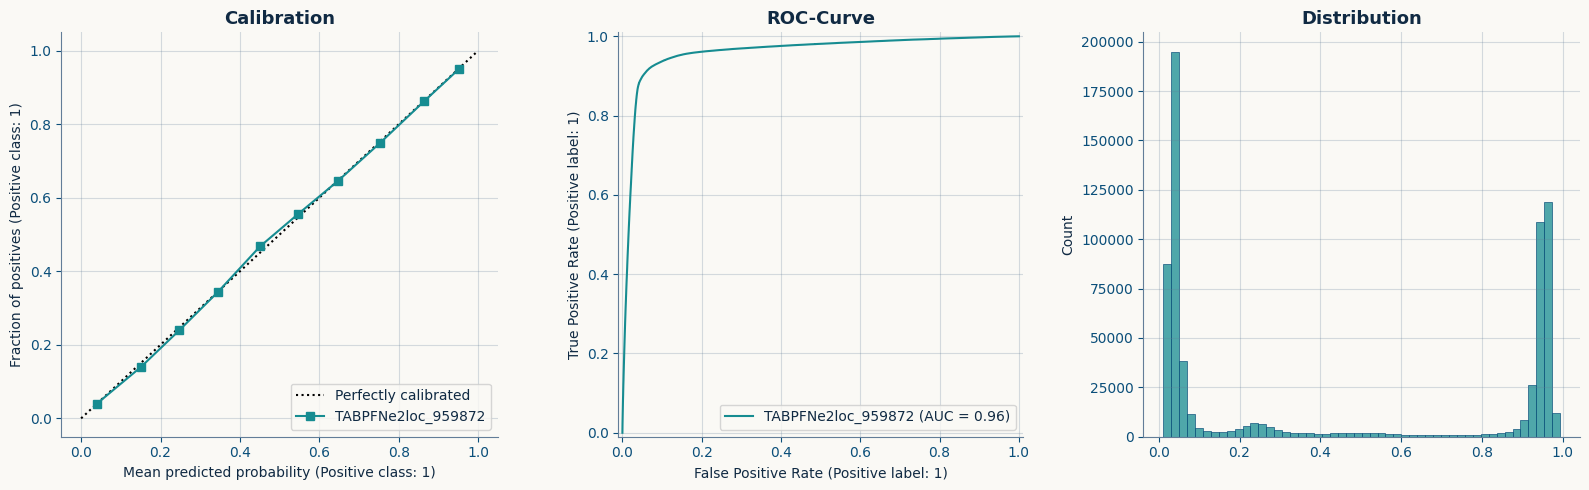


TABPFNe2locm_959748 saved!


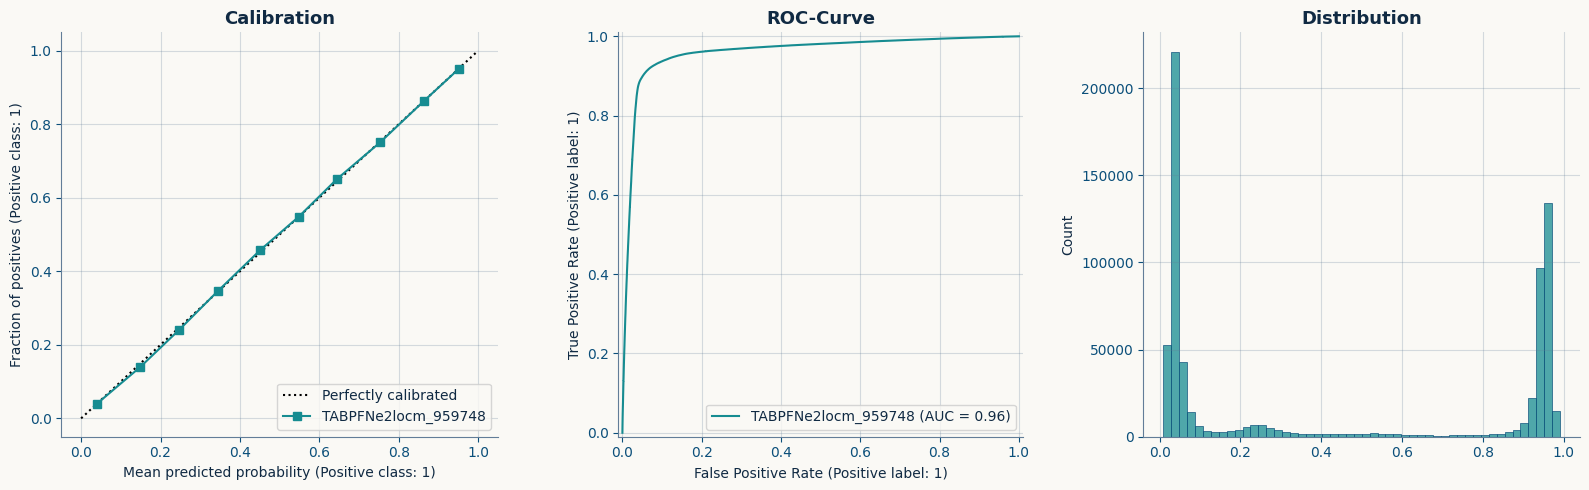

In [29]:
## -- Get oof predictions --
oof_predictions = []

for i, (k, v) in enumerate(all_predictions.items()):
    for key_, val_ in v.items():
        if key_ == "oof_preds":
            ## -- Save oof predictions --
            n = f"{k}_{str(all_scores[k]).split('.')[1]}"
            np.save(f"oof_{n}.npy", val_)
            print(f"{n} saved!")

            ## -- Plot oof distributions --
            _, axs = plt.subplots(1, 3, figsize=(16, 5)) 
            CalibrationDisplay.from_predictions(train_X[TARGET], val_, n_bins=10, name=n, ax=axs[0])
            axs[0].set_title(f"Calibration")

            RocCurveDisplay.from_predictions(train_X[TARGET], val_, name=n, ax=axs[1])
            axs[1].set_title(f"ROC-Curve")

            sns.histplot(val_, ax=axs[2], bins=50)
            axs[2].set_title(f"Distribution")
            
            plt.tight_layout()
            plt.show()

            print()

In [30]:
## -- Save test predictions/submissions --
model_results = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for j, (x, y) in enumerate(v.items()):
        if x == "test_preds":
            ## -- Base submission file --
            n = f"{k}_{str(all_scores[k]).split('.')[1]}"
            np.save(f"test_{n}.npy", y)

            submit[TARGET] = y
            submit.to_csv(f"submit_{n}.csv", index=False)
            print(f"{n} saved! {y.shape}")

            model_results[n[:-6]] = y

print()
model_results = pd.DataFrame(model_results)
model_results

TABPFNe2loc_959872 saved! (299844,)
TABPFNe2locm_959748 saved! (299844,)



,TABPFNe2loc_,TABPFNe2locm_
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0
...,...,...
299839,0.0,0.0
299840,0.0,0.0
299841,0.0,0.0
299842,0.0,0.0


In [ ]:
# !rm -r /kaggle/working